<a href="https://colab.research.google.com/github/theyugster/Intro_To_ML/blob/main/Intro_to_ML(Decision_Trees).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics
import seaborn as sns

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("salihacur/diabetes")

print("Path to dataset files:", path)

100%|██████████| 8.91k/8.91k [00:00<00:00, 13.8MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/salihacur/diabetes/versions/2


In [3]:
import os
print(os.listdir(path))

['diabetes.csv']


In [4]:
df = pd.read_csv(f"{path}/diabetes.csv")
print(df.shape)
df.head()

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [6]:
feature_cols = ["Pregnancies","Glucose","BloodPressure","Insulin","BMI","Age",
"DiabetesPedigreeFunction"]
x = df[feature_cols]
y = df.Outcome
print(x)
print(y)

     Pregnancies  Glucose  BloodPressure  Insulin   BMI  Age  \
0              6      148             72        0  33.6   50   
1              1       85             66        0  26.6   31   
2              8      183             64        0  23.3   32   
3              1       89             66       94  28.1   21   
4              0      137             40      168  43.1   33   
..           ...      ...            ...      ...   ...  ...   
763           10      101             76      180  32.9   63   
764            2      122             70        0  36.8   27   
765            5      121             72      112  26.2   30   
766            1      126             60        0  30.1   47   
767            1       93             70        0  30.4   23   

     DiabetesPedigreeFunction  
0                       0.627  
1                       0.351  
2                       0.672  
3                       0.167  
4                       2.288  
..                        ...  
763    

In [7]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=0)
print(x_train.shape,y_train.shape,x_test.shape,y_test.shape)

(576, 7) (576,) (192, 7) (192,)


In [8]:
model = DecisionTreeClassifier(criterion='entropy',random_state =5)
model.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy', random_state=5)

In [9]:
y_pred = model.predict(x_test)
print(y_pred)

[1 0 0 1 0 0 1 1 0 1 1 1 0 0 0 1 1 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 1
 0 1 1 0 0 1 1 1 0 0 0 0 0 0 1 1 1 0 0 1 1 0 0 1 0 0 1 1 0 1 0 1 1 0 0 0 1
 1 1 0 1 0 0 0 0 0 0 0 0 0 0 1 0 1 1 0 0 1 0 0 0 0 1 0 0 0 0 0 1 0 1 0 0 0
 1 1 1 1 1 0 0 0 1 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 1 0 0 0
 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 1 1 1 0 1 0 0 0 0 1 1 0 0 0 0 0 0 1 0 1 1
 0 1 0 1 0 0 1]


In [10]:
conf_mat = metrics.confusion_matrix(y_test,y_pred)
print(conf_mat)
accuracy = metrics.accuracy_score(y_test,y_pred)
print(accuracy)

[[104  26]
 [ 22  40]]
0.75


<Axes: xlabel='Predicted', ylabel='Actual'>

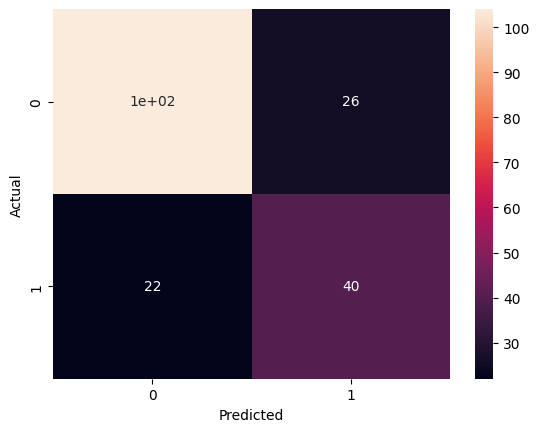

In [11]:
conf_mat = pd.crosstab(y_test,y_pred,rownames=["Actual"],colnames=["Predicted"])
sns.heatmap(conf_mat,annot=True)

In [29]:


# Download latest version
path = kagglehub.dataset_download("janiobachmann/bank-marketing-dataset")

print("Path to dataset files:", path)


100%|██████████| 142k/142k [00:00<00:00, 36.7MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/janiobachmann/bank-marketing-dataset/versions/1


In [30]:
import os
print(os.listdir(path))

['bank.csv']


In [33]:
df = pd.read_csv(f"{path}/bank.csv")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [35]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [36]:
feature_cols = ["age","balance"]
x = df[feature_cols]
y = df.housing
print(x)
print(y)

       age  balance
0       59     2343
1       56       45
2       41     1270
3       55     2476
4       54      184
...    ...      ...
11157   33        1
11158   39      733
11159   32       29
11160   43        0
11161   34        0

[11162 rows x 2 columns]
0        yes
1         no
2        yes
3        yes
4         no
        ... 
11157    yes
11158     no
11159     no
11160     no
11161     no
Name: housing, Length: 11162, dtype: object


In [37]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=0)
print(x_train.shape,y_train.shape,x_test.shape,y_test.shape)

(8371, 2) (8371,) (2791, 2) (2791,)


In [38]:
model = DecisionTreeClassifier(criterion='entropy',random_state =5)
model.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy', random_state=5)

In [39]:
y_pred = model.predict(x_test)
print(y_pred)

['no' 'no' 'yes' ... 'yes' 'yes' 'yes']


In [40]:
conf_mat = metrics.confusion_matrix(y_test,y_pred)
print(conf_mat)
accuracy = metrics.accuracy_score(y_test,y_pred)
print(accuracy)

[[912 545]
 [577 757]]
0.5979935506986743


<Axes: xlabel='Predicted', ylabel='Actual'>

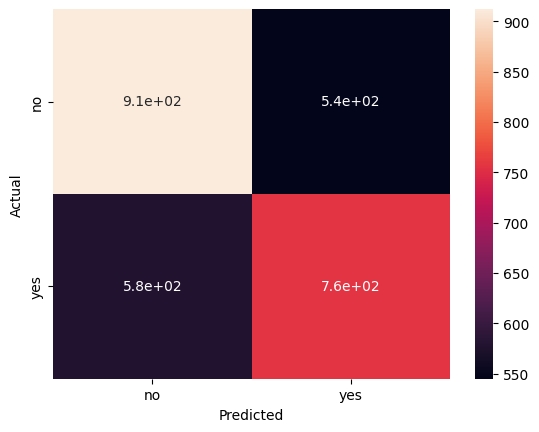

In [41]:
conf_mat = pd.crosstab(y_test,y_pred,rownames=["Actual"],colnames=["Predicted"])
sns.heatmap(conf_mat,annot=True)

In [42]:

# Download latest version
path = kagglehub.dataset_download("dheemanthbhat/simple-weather-forecast")

print("Path to dataset files:", path)


100%|██████████| 322/322 [00:00<00:00, 720kB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/dheemanthbhat/simple-weather-forecast/versions/1


In [55]:
import os
print(os.listdir(path))

['weather_forecast.csv']


In [56]:
df = pd.read_csv(f"{path}/weather_forecast.csv")
df.head()

,Outlook,Temperature,Humidity,Windy,Play
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes


In [57]:
df.head()

,Outlook,Temperature,Humidity,Windy,Play
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes


In [58]:
df = pd.get_dummies(df, columns=['Outlook', 'Temperature', 'Humidity', 'Windy'])
df.head()

,Play,Outlook_Overcast,Outlook_Rain,Outlook_Sunny,Temperature_Cool,Temperature_Hot,Temperature_Mild,Humidity_High,Humidity_Normal,Windy_Strong,Windy_Weak
0,No,False,False,True,False,True,False,True,False,False,True
1,No,False,False,True,False,True,False,True,False,True,False
2,Yes,True,False,False,False,True,False,True,False,False,True
3,Yes,False,True,False,False,False,True,True,False,False,True
4,Yes,False,True,False,True,False,False,False,True,False,True


In [59]:
feature_cols = ["Outlook_Overcast","Outlook_Rain","Outlook_Sunny","Temperature_Cool","Temperature_Hot","Temperature_Mild","Temperature_Mild","Humidity_Normal","Windy_Strong","Windy_Strong"]
x = df[feature_cols]
y = df.Play
print(x)
print(y)

    Outlook_Overcast  Outlook_Rain  Outlook_Sunny  Temperature_Cool  \
0              False         False           True             False   
1              False         False           True             False   
2               True         False          False             False   
3              False          True          False             False   
4              False          True          False              True   
5              False          True          False              True   
6               True         False          False              True   
7              False         False           True             False   
8              False         False           True              True   
9              False          True          False             False   
10             False         False           True             False   
11              True         False          False             False   
12              True         False          False             False   
13    

In [60]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=0)
print(x_train.shape,y_train.shape,x_test.shape,y_test.shape)

(10, 10) (10,) (4, 10) (4,)


In [61]:
model = DecisionTreeClassifier(criterion='entropy',random_state =5)
model.fit(x_train,y_train)


DecisionTreeClassifier(criterion='entropy', random_state=5)

In [62]:
y_pred = model.predict(x_test)
print(y_pred)

['No' 'Yes' 'No' 'Yes']


In [63]:
conf_mat = metrics.confusion_matrix(y_test,y_pred)
print(conf_mat)
accuracy = metrics.accuracy_score(y_test,y_pred)
print(accuracy)

[[0 0]
 [2 2]]
0.5


<Axes: xlabel='Predicted', ylabel='Actual'>

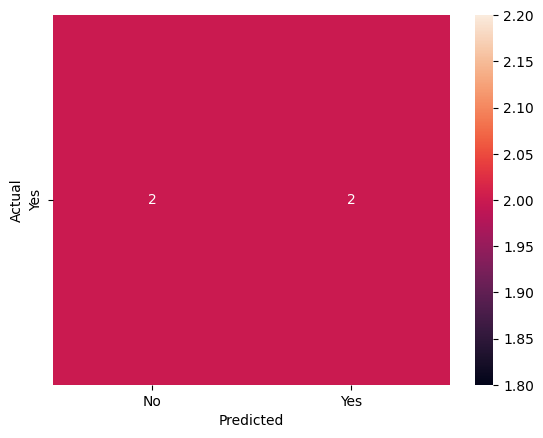

In [64]:
conf_mat = pd.crosstab(y_test,y_pred,rownames=["Actual"],colnames=["Predicted"])
sns.heatmap(conf_mat,annot=True)